# A2 — Knowledge-Base Demo (fill this)
Show OCR quality on a sample and one working retrieval example.

In [1]:

from pathlib import Path
import sys
import os

REPO_DIR = Path.cwd().parent

SRC_DIR = REPO_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(REPO_DIR)

from doc_agent import config, pipeline
from doc_agent.retrieval.retriever import Retriever

print(f"Repository: {REPO_DIR}")
print(f"Python: {sys.executable}")
print(f"Working directory: {Path.cwd()}")

Repository: f:\DL_project\doc-agent-G04
Python: f:\DL_project\doc-agent-G04\.venv\Scripts\python.exe
Working directory: f:\DL_project\doc-agent-G04


In [2]:
cfg = config.load()

print("Configuration loaded.")
print("OCR backend:", cfg["ocr"].get("backend"))
print("Embedding model:", cfg["embed"].get("model"))
print("Index type:", cfg["index"].get("type"))

Configuration loaded.
OCR backend: tesseract
Embedding model: sentence-transformers/all-MiniLM-L6-v2
Index type: faiss:flat-ip


In [ ]:
print("Building knowledge base...")

pipeline.build_knowledge_base(cfg)

print("Knowledge-base build completed.")

Building knowledge base...
starting
Pages loaded
Pages pre processed
Regions detected
[Chunk(id='default__higher_math_page_0001__region_0000', doc_id='default', text='নবম ও দশম শ্রোণ', page_ids=['default__higher_math_page_0001'], score=0.0), Chunk(id='default__higher_math_page_0002__region_0000', doc_id='default', text='জাতীয় শিক্ষাক্রম ও পাঠ্যপুস্তক বোর্ড কর্তৃক ২০১৩ শিক্ষাবর্ষ থেকে\nনবম ও দশম শ্রেণির পাঠ্যপুস্তকরপে নির্ধারিত\nউচ্চতর গণিত\nনবম ও দশম শ্্রোণ\n২০২৬ শিক্ষাবর্ষের জন্য পরিমার্জিত\nজাতীয় শিক্ষাক্রম ও পাঠ্যপুস্তক বোর্ড, বাংলাদেশ', page_ids=['default__higher_math_page_0002'], score=0.0), Chunk(id='default__higher_math_page_0003__region_0000', doc_id='default', text='জাতীয় শিক্ষাক্রম ও পাঠ্যপুস্তক বোর্ড\n৬৯-৭০ মতিঝিল বাণিজ্যিক এলাকা, ঢাকা-১০০০\nকর্তক প্রকাশিত\n[প্রকাশক কর্তৃক সর্বস্বত্ব সংরক্ষিত]\nপ্রথম সংস্করণ রচনা ও সম্পাদনা\nড. মোঃ আব্দুল মতিন\nড. মোঃ আইনুল ইসলাম\nড. অমূল্য চন্দ্র মণ্ডল\nড. মোঃ আব্দুস ছামাদ\nড. মোঃ আব্দুল হালিম\nড. শাহাদৎ আলি মল্লিক\nপ্রথম প্রকাশ : সেপ্টে

f:\DL_project\doc-agent-G04\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
f:\DL_project\doc-agent-G04\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.         -0.03490024
   0.        ]
 [ 0.03846154  0.          0.         ...  0.07692308 -0.03846154
   0.        ]
 [ 0.          0.          0.         ... -0.08304548  0.
   0.        ]]
Entering vector store
Knowledge-base build completed.


In [11]:
raw_path = (
    REPO_DIR
    / "data"
    / "raw"
    / "higher_math_page_0016.png"
)

preprocessed_path = (
    REPO_DIR
    / "data"
    / "interim"
    / "preprocessed"
    / "default"
    / "higher_math_page_0016.png"
)

layout_path = (
    REPO_DIR
    / "reports"
    / "figures"
    / "layout"
    / "default"
    / "higher_math_page_0016.png"
)

for path in [raw_path, preprocessed_path, layout_path]:
    print(path)
    print("exists:", path.is_file())
    print()

f:\DL_project\doc-agent-G04\data\raw\higher_math_page_0016.png
exists: True

f:\DL_project\doc-agent-G04\data\interim\preprocessed\default\higher_math_page_0016.png
exists: True

f:\DL_project\doc-agent-G04\reports\figures\layout\default\higher_math_page_0016.png
exists: True



Original page size: (2175, 2850)


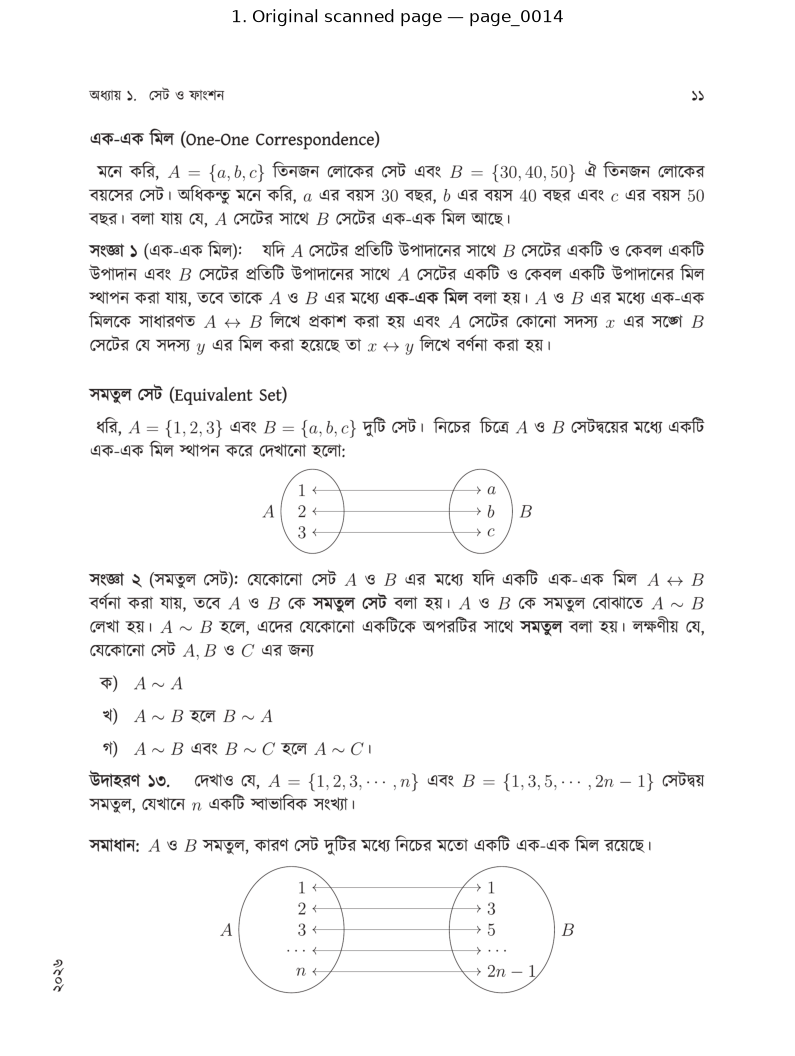

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
raw_image = Image.open(raw_path)

print("Original page size:", raw_image.size)

plt.figure(figsize=(10, 14))
plt.imshow(raw_image)
plt.axis("off")
plt.title("1. Original scanned page — page_0014")
plt.show()

Preprocessed page size: (2175, 2850)


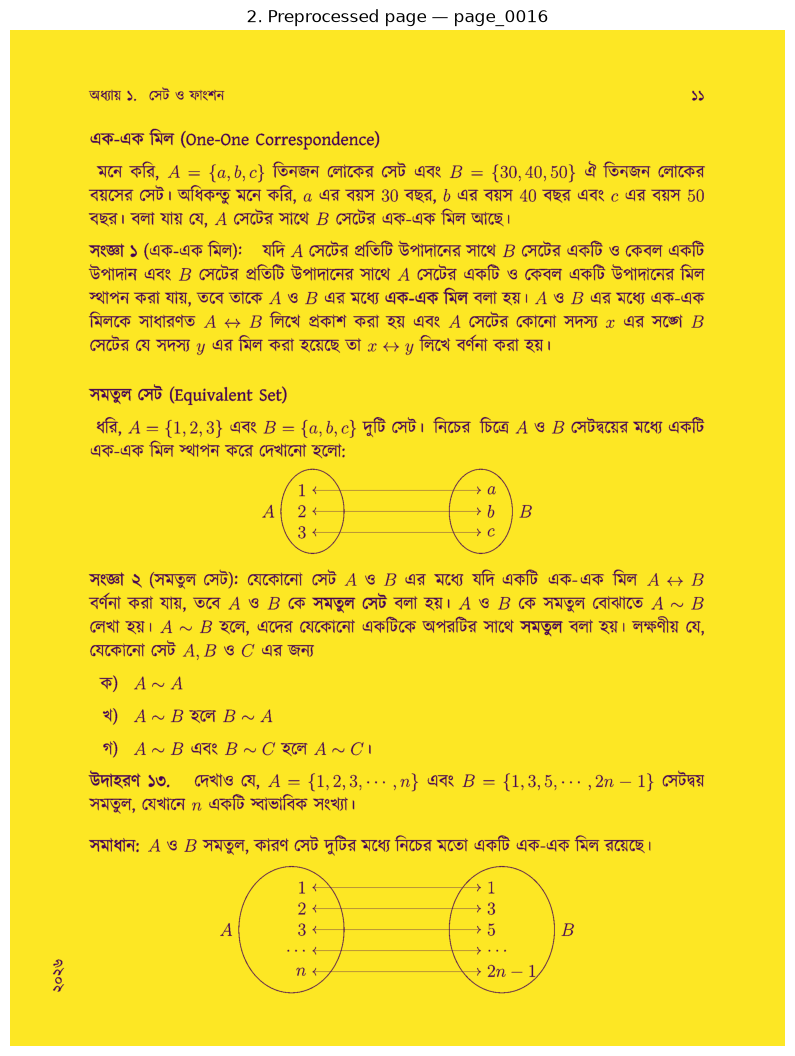

In [13]:
preprocessed_image = Image.open(preprocessed_path)

print("Preprocessed page size:", preprocessed_image.size)

plt.figure(figsize=(10, 14))
plt.imshow(preprocessed_image)
plt.axis("off")
plt.title("2. Preprocessed page — page_0016")
plt.show()

Layout visualization size: (2175, 2850)


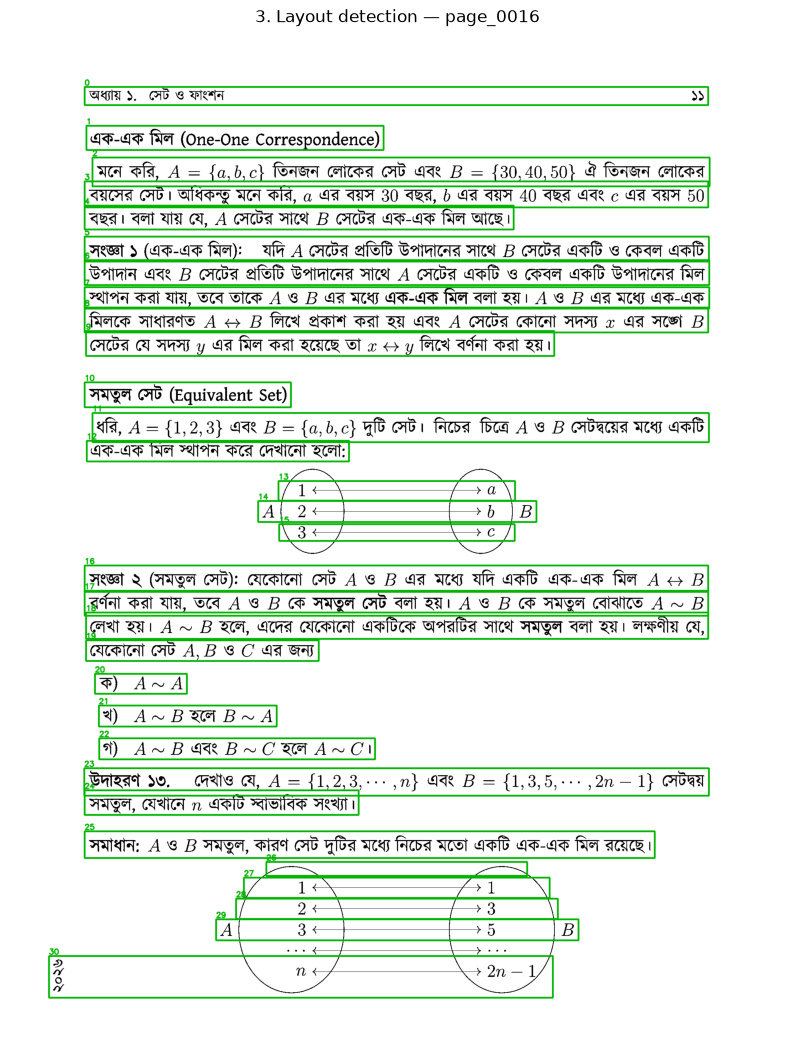

In [14]:
layout_image = Image.open(layout_path)

print("Layout visualization size:", layout_image.size)

plt.figure(figsize=(10, 14))
plt.imshow(layout_image)
plt.axis("off")
plt.title("3. Layout detection — page_0016")
plt.show()

In [20]:
from doc_agent.contracts import Page
from doc_agent.vision import layout

page = Page(
    id="default__higher_math_page_0016",
    image_path=str(preprocessed_path),
    doc_id="default",
)

regions = layout.detect([page], cfg)

print(f"Detected {len(regions)} regions on page_0016")
for i, region in enumerate(regions[:10]):
    print(i, region.page_id, region.kind, region.bbox)


Detected 31 regions on page_0016
0 default__higher_math_page_0016 text (209, 158, 1750, 51)
1 default__higher_math_page_0016 text (214, 267, 834, 68)
2 default__higher_math_page_0016 text (231, 356, 1732, 81)
3 default__higher_math_page_0016 text (209, 423, 1750, 73)
4 default__higher_math_page_0016 text (209, 491, 1204, 67)
5 default__higher_math_page_0016 text (209, 578, 1752, 70)
6 default__higher_math_page_0016 text (209, 644, 1753, 70)
7 default__higher_math_page_0016 text (209, 720, 1753, 60)
8 default__higher_math_page_0016 text (209, 777, 1750, 70)
9 default__higher_math_page_0016 text (213, 843, 1314, 70)


In [21]:
from doc_agent.vision import ocr

reader = ocr.Reader(cfg)
ocr_results = []

for i, region in enumerate(regions):
    if region.kind not in {"text", "heading"}:
        continue

    text = reader.transcribe_region(region)
    if text:
        ocr_results.append(
            {
                "region_index": i,
                "kind": region.kind,
                "bbox": region.bbox,
                "text": text,
            }
        )

print(f"OCR extracted text from {len(ocr_results)} regions.")
for item in ocr_results[:5]:
    print(f"\n[{item['region_index']}] {item['kind']} {item['bbox']}")
    print(item['text'][:400])
    print("-" * 80)


OCR extracted text from 30 regions.

[0] text (209, 158, 1750, 51)
অধ্যায় ১. সেট ও ফাংশন ১১
--------------------------------------------------------------------------------

[1] text (214, 267, 834, 68)
এক-এক মিল (One-One Correspondence)
--------------------------------------------------------------------------------

[2] text (231, 356, 1732, 81)
মনে করি, A = {a,b,c} তিনজন লোকের সেট এবং B = {30,40,50} এঁ তিনজন লোকের
--------------------------------------------------------------------------------

[3] text (209, 423, 1750, 73)
বয়সের সেট | অধিকন্তু মনে করি, ৫ এর বয়স 30 বছর, b এর বয়স 40 বছর এবং ০ এর বয়স 50
--------------------------------------------------------------------------------

[4] text (209, 491, 1204, 67)
বছর। বলা যায় যে, A সেটের সাথে B সেটের এক-এক মিল আছে।
--------------------------------------------------------------------------------


In [22]:
from doc_agent import pipeline

# Run the earlier stages again only if your pipeline exposes
# intermediate OCR output. Otherwise, inspect the generated
# preprocessed/OCR artifacts according to your project structure.

print("OCR backend:", cfg["ocr"].get("backend"))
print("OCR model/language:", cfg["ocr"].get("languages", cfg["ocr"].get("model")))

OCR backend: tesseract
OCR model/language: ben+eng


In [23]:
from doc_agent.vision import ocr
from doc_agent import contracts

print("OCR implementation loaded:")
print(ocr.Reader)

OCR implementation loaded:
<class 'doc_agent.vision.ocr.Reader'>


In [24]:
retriever = Retriever(cfg)

query = "সেট এবং ফাংশন সম্পর্কিত ধারণা"

results = retriever.retrieve(query, k=3)

print(f"Query: {query}")
print(f"Retrieved {len(results)} results\n")

for rank, hit in enumerate(results, start=1):
    page = hit.page_ids[0] if hit.page_ids else "unknown"

    print(f"#{rank}")
    print(f"Score: {hit.score:.3f}")
    print(f"Page:  {page}")
    print(f"ID:    {hit.id}")
    print("-" * 70)
    print(hit.text)
    print("=" * 70)

f:\DL_project\doc-agent-G04\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Query: সেট এবং ফাংশন সম্পর্কিত ধারণা
Retrieved 3 results

#1
Score: 0.379
Page:  default__higher_math_page_0006
ID:    default__higher_math_page_0006__region_0000__chunk_0000
----------------------------------------------------------------------
অধ্যায় ১ সেট ও ফাংশন (Set and Function) সেটের ধারণা ও ব্যবহার গণিতে বিশেষ গুরুত্বপূর্ণ। এ জন্য অষ্টম ও নবম-দশম শ্রেণির গণিত বইতে সেট সম্পর্কে আলোচনা করা হয়েছে। এ অধ্যায়ে তার বিস্তৃতি হিসেবে আরও আলোচনা করা হলো। এ অধ্যায় শেষে শিক্ষার্থীরা - ৯ সার্বিক সেট, উপসেট, পূরক সেট ও শক্তি সেট গঠন করতে পারবে; ৯. বিভিন্ন সেটের সংযোগ, ছেদ ও অন্তর নির্ণয় করতে পারবে; ৯ সেট প্রক্রিয়ার ধর্মাবলির EIT প্রমাণ করতে পারবে; ৯. সমতুল সেট বর্ণনা করতে পারবে এবং এর মাধ্যমে অসীম সেটের ধারণা ব্যাখ্যা করতে পারবে; > সেটের সংযোগের শত্তি সেট নির্ণয়ের সূত্র ব্যাখ্যা করতে পারবে এবং ভেনচিত্র ও উদাহরণের সাহায্যে তা যাচাই করতে পারবে; > সেট প্রক্রিয়া প্রয়োগ করে জীবনভিত্তিক সমস্যা সমাধান করতে পারবে; ৯ সেটের সাহায্যে অন্বযয় ও ফাংশন এর ধারণা ব্যাখ্যা করতে পারবে; ৯. ফাংশনের ডোমে

In [25]:
query = "বহুপদী কাকে বলে? বহুপদীর উদাহরণ"

results = retriever.retrieve(query, k=3)

for rank, hit in enumerate(results, start=1):
    page = hit.page_ids[0] if hit.page_ids else "unknown"

    print(f"\n#{rank} | score={hit.score:.3f} | page={page}")
    print(hit.text)
    print("-" * 80)


#1 | score=0.214 | page=default__higher_math_page_0046
অধ্যায় ২. বীজগাণিতিক রাশি ৪১ বহুপদীর গুণফল ও ভাগফল দুটি বহুপদীর যোগফল, বিয়োগফল এবং গুণফল সবসময় gen হয়। দুটি বনহ্ুপদীর ভাগফল বহুপদী হতেও পারে নাও হতে পারে। যেমন 2 দ্বারা ? কে ভাগ করলে ভাগফল যদি -2 ধরা হয় তখন এটি বহুপদী নয়। কিন্তু : কে ভাগশেষ ধরে নিলে সেক্ষেত্রে ভাগফল 0 একটি age উদাহরণ ২. (2% +2) কে (৫ 47 1) দ্বারা গুণ করলে গুণফল কত? এখানে (2? +2) এবং (৫ 71) বহুপদী দুটির গুণফল (2? + 2)(৫ + 1) = 2° + 22 + 22 + 2 একটি বহুপদী যার মাত্রা 271 - 3 এবং মুখ্যসহগ 1 1 = 11 উদাহরণ ৩. (৫১+1)(2 — 6)কে 222 + 3 দ্বারা ভাগ করলে ভাগফল কত? এখানে ভাজ্য Pz) = (22+ 1)(z — 6) = 2° — 62% + ৫ — 6 এর মাত্রা 3 এবং মুখ্যসহগ 1 | আর ভাজক Q(z) = 222 + 3 এর মাত্রা 2 এবং JRA 2 | P(x) কে Q(z) দিয়ে ভাগ করলে, ভাগফল F(z) = pe” — 3 এবং ভাগশেষ R(x) = — : +31 কাজেই, ভাগফল F(z) একটি বহুপদী যার মাত্রা 3 — 2 = 1 এবং মুখ্যসহগ ন্‌ !
--------------------------------------------------------------------------------

#2 | score=0.187 | page=default__higher_math_page_0043
অ